# Orçamento federal em saúde, segurança pública e educação (2001–2025)

Este estudo compara a execução orçamentária federal nas três funções ao longo dos últimos 25 exercícios completos. A fonte é o orçamento aberto do **SIOP/MPO**, consultado por função nos grafos anuais do endpoint SPARQL. A classificação oficial usa os códigos 10 (Saúde), 06 (Segurança Pública) e 12 (Educação).

**“Investimento” tem dois sentidos neste estudo:** a medida principal é o total pago em cada função, que inclui pessoal, custeio, transferências e capital. Em separado, mostramos o **GND 4 — Investimentos**, a categoria contábil de investimento de capital dentro de cada função. Assim, o gráfico de gasto total não deve ser interpretado como gasto exclusivamente em obras ou equipamentos.

Fonte: [SIOP — Dados Abertos do Orçamento Federal](https://orcamento.dados.gov.br/siopdoc/doku.php/acesso_publico:dados_abertos/) e [documentação das consultas SPARQL](https://orcamento.dados.gov.br/siopdoc/doku.php/acesso_publico:scripts_sparql). Os arquivos coletados, consultas anuais e cobertura estão descritos em [data/README.md](../data/README.md).

**Escopo e limites:** dados da execução do orçamento federal (orçamentos Fiscal e da Seguridade Social), não o gasto total de União, estados e municípios. O exercício de 2026 foi deixado de fora porque ainda estava em andamento na coleta. Pagamento mede execução financeira, não qualidade ou resultado do serviço; transferências federais são atribuídas à função orçamentária da União e não incluem a despesa posterior dos governos recebedores.

## 1. Carregar as séries e corrigir os valores pela inflação

Os valores nominais são apresentados em R$ bilhões correntes. Para comparar o poder de compra entre anos, calculamos também valores em **R$ médios de 2025**, usando as variações mensais do IPCA do Banco Central. Para fluxos anuais, o deflator é baseado na média do índice de preços de cada ano.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "data" / "processed").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / "data" / "processed"

gasto = pd.read_csv(DATA / "orcamento_saude_seguranca_educacao.csv")
ipca = pd.read_csv(DATA / "bcb_divida_ipca_mensal.csv", parse_dates=["data"])

gasto["ano"] = gasto.ano.astype(int)
for coluna in ["despesa_paga_r$", "despesa_liquidada_r$", "gnd4_investimento_pago_r$", "gnd4_investimento_liquidado_r$"]:
    gasto[coluna.replace("_r$", "_r_bilhoes")] = gasto[coluna] / 1e9

precos = ipca.dropna(subset=["ipca_variacao_mensal_percentual"]).sort_values("data").copy()
precos["indice_precos"] = (1 + precos["ipca_variacao_mensal_percentual"] / 100).cumprod()
precos["ano"] = precos.data.dt.year
indice_anual = precos.groupby("ano").indice_precos.mean()
base_2025 = indice_anual.loc[2025]
deflator = (base_2025 / indice_anual).rename("deflator_r_2025").reset_index()
gasto = gasto.merge(deflator, on="ano", how="left")
gasto["pago_real_2025_r_bilhoes"] = gasto.despesa_paga_r_bilhoes * gasto.deflator_r_2025
gasto["gnd4_pago_real_2025_r_bilhoes"] = gasto.gnd4_investimento_pago_r_bilhoes * gasto.deflator_r_2025
gasto["investimento_gnd4_sobre_total_pct"] = 100 * gasto.gnd4_investimento_pago_r_bilhoes / gasto.despesa_paga_r_bilhoes

ordem = ["Saúde", "Educação", "Segurança Pública"]
gasto["funcao"] = gasto.funcao.str.strip()
gasto["funcao"] = pd.Categorical(gasto.funcao, categories=ordem, ordered=True)
gasto = gasto.sort_values(["ano", "funcao"])

print(f"Período: {gasto.ano.min()}–{gasto.ano.max()} ({gasto.ano.nunique()} exercícios completos)")
print("Funções:", ", ".join(map(str, gasto.funcao.cat.categories)))
print(f"Linhas: {len(gasto)} (uma por exercício e função)")

Período: 2001–2025 (25 exercícios completos)
Funções: Saúde, Educação, Segurança Pública
Linhas: 75 (uma por exercício e função)


## 2. Quanto foi pago em cada área?

A tabela usa valores reais para mostrar a evolução do gasto em termos comparáveis, não apenas o efeito de preços. Os pagamentos anuais podem oscilar por calendários de desembolso e pagamentos de obrigações de exercícios anteriores.

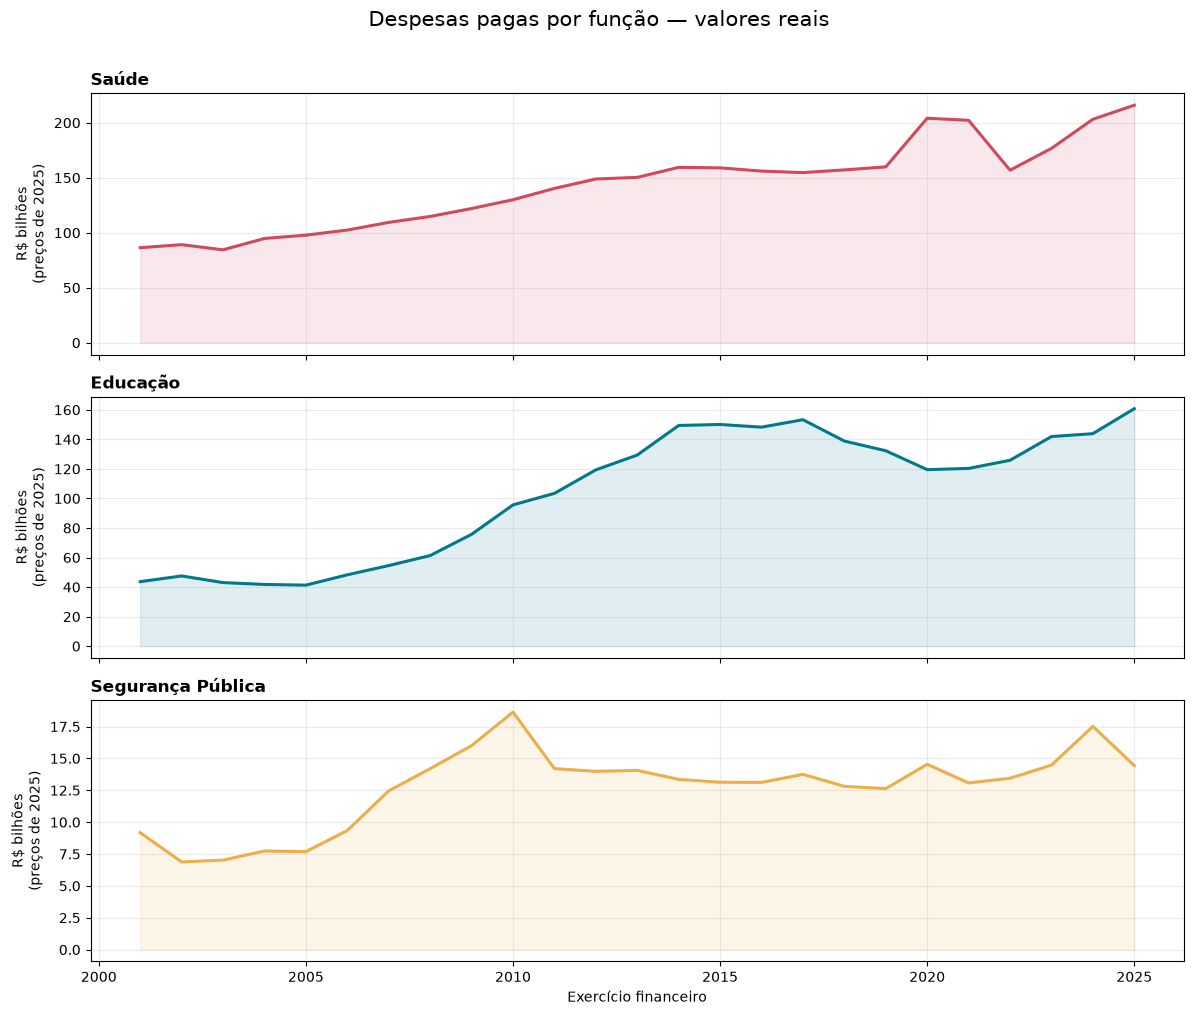

ano,2001,2010,2015,2020,2025
Função — R$ bi de 2025,,,,,
Saúde,86.4,130.0,159.0,204.1,216.0
Educação,43.7,95.6,150.1,119.5,160.8
Segurança Pública,9.2,18.6,13.1,14.5,14.4


In [2]:
real = gasto.pivot(index="ano", columns="funcao", values="pago_real_2025_r_bilhoes")
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
cores = {"Saúde":"#d1495b", "Educação":"#00798c", "Segurança Pública":"#edae49"}
for ax, funcao in zip(axes, ordem):
    ax.plot(real.index, real[funcao], color=cores[funcao], linewidth=2.2)
    ax.fill_between(real.index, real[funcao], color=cores[funcao], alpha=.12)
    ax.set_title(funcao, loc="left", fontweight="bold")
    ax.set_ylabel("R$ bilhões\n(preços de 2025)")
    ax.grid(alpha=.25)
axes[-1].set_xlabel("Exercício financeiro")
fig.suptitle("Despesas pagas por função — valores reais", fontsize=15, y=1.01)
fig.tight_layout()
plt.show()

# Tabela de marcos: valores reais e nominais, além do item GND 4.
marcos = gasto[gasto.ano.isin([2001, 2010, 2015, 2020, 2025])].pivot(
    index="funcao", columns="ano", values="pago_real_2025_r_bilhoes"
).reindex(ordem)
display(marcos.round(1).rename_axis("Função — R$ bi de 2025"))

## 3. Comparar o ritmo de crescimento

O índice abaixo fixa cada função em 100 no primeiro exercício da série. Ele compara o crescimento real relativo, mas não significa que as áreas começaram com o mesmo volume de recursos.

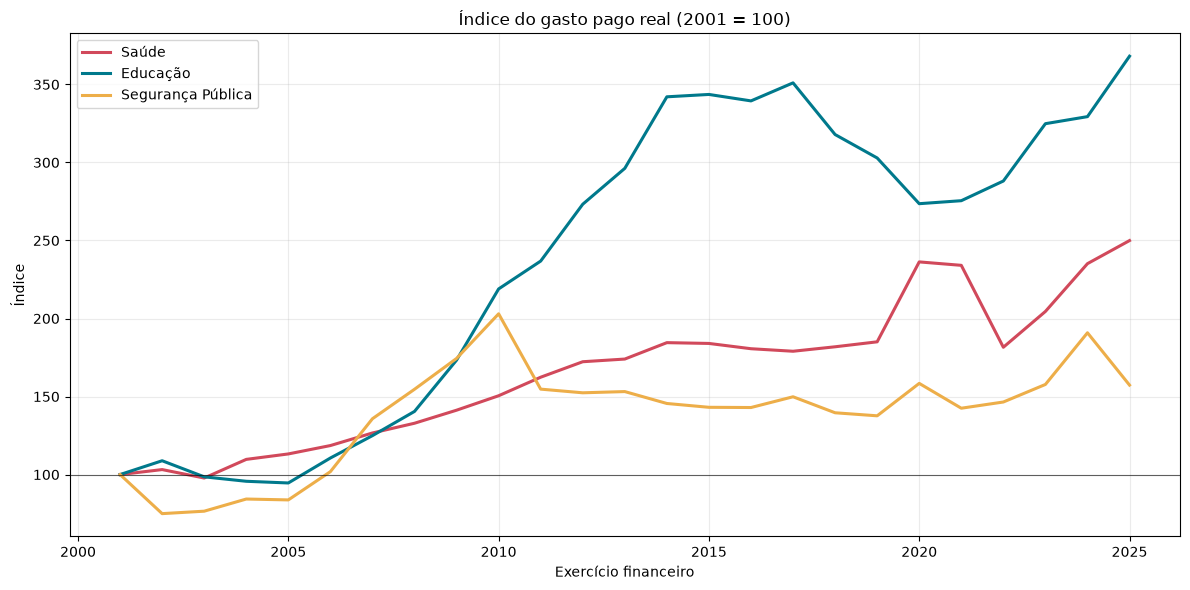

,2001 (R$ bi de 2025),2025 (R$ bi de 2025),Variação real (%),Fator real
Função,,,,
Saúde,86.4,216.0,149.9,2.5
Educação,43.7,160.8,268.1,3.7
Segurança Pública,9.2,14.4,57.3,1.6


In [3]:
indice = real.div(real.iloc[0]).mul(100)
fig, ax = plt.subplots(figsize=(12, 6))
for funcao in ordem:
    ax.plot(indice.index, indice[funcao], label=funcao, color=cores[funcao], linewidth=2.2)
ax.axhline(100, color="black", linewidth=.8, alpha=.6)
ax.set_title("Índice do gasto pago real (2001 = 100)")
ax.set_ylabel("Índice")
ax.set_xlabel("Exercício financeiro")
ax.grid(alpha=.25)
ax.legend()
plt.tight_layout()
plt.show()

resumo = []
for funcao in ordem:
    inicial, final = real.loc[2001, funcao], real.loc[2025, funcao]
    resumo.append({"Função":funcao, "2001 (R$ bi de 2025)":inicial, "2025 (R$ bi de 2025)":final,
                   "Variação real (%)":100*(final/inicial-1), "Fator real":final/inicial})
display(pd.DataFrame(resumo).set_index("Função").round(1))

## 4. O sentido contábil de investimento: GND 4

O grupo de natureza da despesa GND 4 identifica investimentos de capital no orçamento federal. O valor pago nesse grupo é uma parte do gasto da função e costuma ser menor que o total: salários, serviços, benefícios e transferências correntes ficam fora do GND 4.

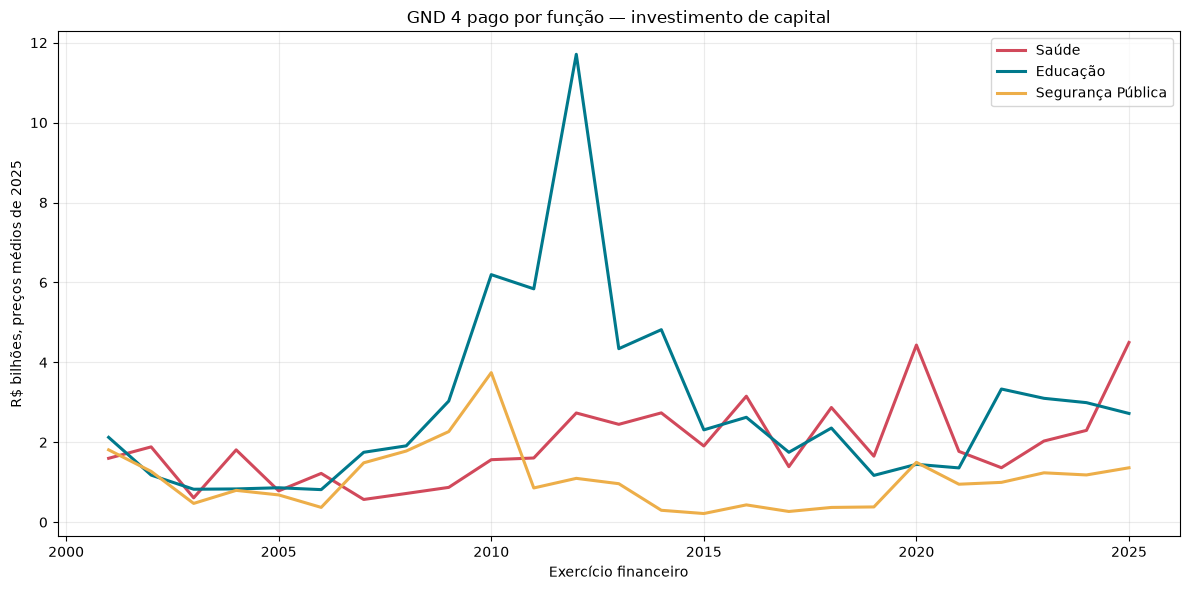

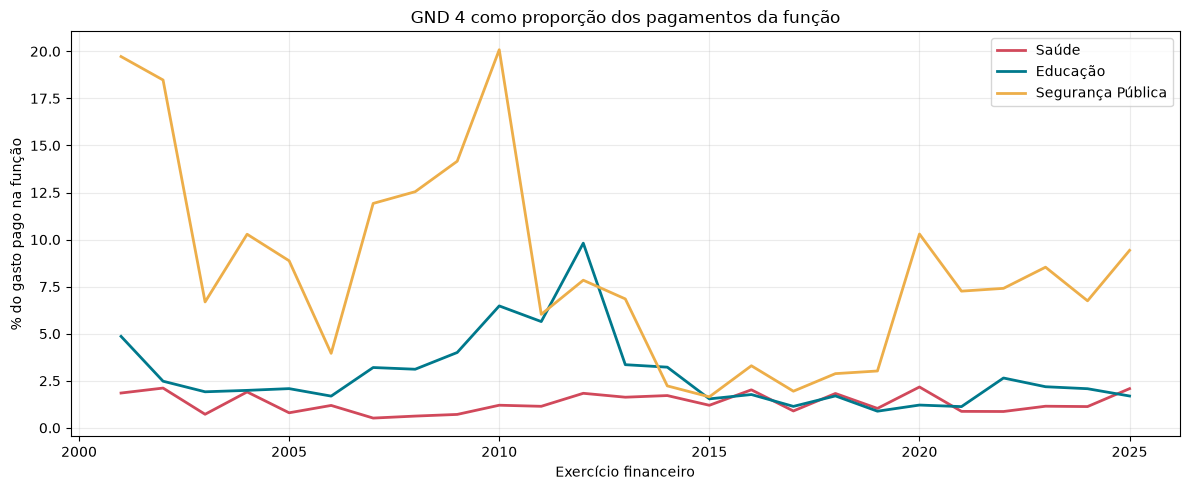

,Total pago nominal (R$ bi),Total pago real (R$ bi de 2025),GND 4 pago nominal (R$ bi),GND 4 pago real (R$ bi de 2025),GND 4 / total (%)
funcao,,,,,
Saúde,215.95,215.95,4.50,4.50,2.08
Educação,160.78,160.78,2.72,2.72,1.69
Segurança Pública,14.44,14.44,1.36,1.36,9.43


In [4]:
gnd4 = gasto.pivot(index="ano", columns="funcao", values="gnd4_pago_real_2025_r_bilhoes").reindex(columns=ordem)
fig, ax = plt.subplots(figsize=(12, 6))
for funcao in ordem:
    ax.plot(gnd4.index, gnd4[funcao], label=funcao, color=cores[funcao], linewidth=2.2)
ax.set_title("GND 4 pago por função — investimento de capital")
ax.set_ylabel("R$ bilhões, preços médios de 2025")
ax.set_xlabel("Exercício financeiro")
ax.grid(alpha=.25)
ax.legend()
plt.tight_layout()
plt.show()

capex_share = gasto.pivot(index="ano", columns="funcao", values="investimento_gnd4_sobre_total_pct").reindex(columns=ordem)
fig, ax = plt.subplots(figsize=(12, 5))
for funcao in ordem:
    ax.plot(capex_share.index, capex_share[funcao], label=funcao, color=cores[funcao], linewidth=2)
ax.set_title("GND 4 como proporção dos pagamentos da função")
ax.set_ylabel("% do gasto pago na função")
ax.set_xlabel("Exercício financeiro")
ax.grid(alpha=.25)
ax.legend()
plt.tight_layout()
plt.show()

tabela_2025 = gasto[gasto.ano.eq(2025)].set_index("funcao")[[
    "despesa_paga_r_bilhoes", "pago_real_2025_r_bilhoes",
    "gnd4_investimento_pago_r_bilhoes", "gnd4_pago_real_2025_r_bilhoes",
    "investimento_gnd4_sobre_total_pct"
]].rename(columns={
    "despesa_paga_r_bilhoes":"Total pago nominal (R$ bi)",
    "pago_real_2025_r_bilhoes":"Total pago real (R$ bi de 2025)",
    "gnd4_investimento_pago_r_bilhoes":"GND 4 pago nominal (R$ bi)",
    "gnd4_pago_real_2025_r_bilhoes":"GND 4 pago real (R$ bi de 2025)",
    "investimento_gnd4_sobre_total_pct":"GND 4 / total (%)"
})
display(tabela_2025.reindex(ordem).round(2))

## 5. Evolução recente e leitura dos dados

Valores pagos não medem diretamente o serviço prestado nem a suficiência do financiamento. A classificação por função permite acompanhar a área orçamentária; a classificação GND 4 mostra a parcela contabilizada como investimento de capital. As duas séries respondem a perguntas diferentes.

In [5]:
# Variação real anual do gasto total pago e do GND 4.
recentes = gasto[gasto.ano.ge(2015)].copy()
recentes["variacao_real_total_pct"] = recentes.groupby("funcao", observed=True).pago_real_2025_r_bilhoes.pct_change() * 100
recentes["variacao_real_gnd4_pct"] = recentes.groupby("funcao", observed=True).gnd4_pago_real_2025_r_bilhoes.pct_change() * 100
variacao_2025 = recentes[recentes.ano.isin([2024, 2025])][["ano", "funcao", "variacao_real_total_pct", "variacao_real_gnd4_pct"]]
display(variacao_2025.set_index(["ano", "funcao"]).round(1))

# Comparação entre o valor liquidado e o pago no exercício mais recente disponível.
fechamento = gasto[gasto.ano.eq(2025)].set_index("funcao")[[
    "despesa_liquidada_r_bilhoes", "despesa_paga_r_bilhoes",
    "gnd4_investimento_liquidado_r_bilhoes", "gnd4_investimento_pago_r_bilhoes"
]].rename(columns={
    "despesa_liquidada_r_bilhoes":"Total liquidado (R$ bi correntes)",
    "despesa_paga_r_bilhoes":"Total pago (R$ bi correntes)",
    "gnd4_investimento_liquidado_r_bilhoes":"GND 4 liquidado (R$ bi correntes)",
    "gnd4_investimento_pago_r_bilhoes":"GND 4 pago (R$ bi correntes)"
})
display(fechamento.reindex(ordem).round(2))

variacao_real_total_pct  variacao_real_gnd4_pct
ano  funcao                                                            
2024 Saúde                                 15.0                    13.1
     Educação                               1.4                    -3.5
     Segurança Pública                     21.0                    -4.3
2025 Saúde                                  6.3                    95.8
     Educação                              11.8                    -9.0
     Segurança Pública                    -17.6                    15.2

,Total liquidado (R$ bi correntes),Total pago (R$ bi correntes),GND 4 liquidado (R$ bi correntes),GND 4 pago (R$ bi correntes)
funcao,,,,
Saúde,218.56,215.95,4.53,4.50
Educação,170.07,160.78,2.79,2.72
Segurança Pública,15.44,14.44,1.37,1.36


## 6. Síntese e limitações

- O orçamento federal mostra a execução anual por função de Saúde, Educação e Segurança Pública entre 2001 e 2025.
- O gasto real em cada área é mais informativo que o valor nominal isolado para comparar anos distantes.
- “Total pago por função” reúne despesas correntes e de capital; **GND 4** é o componente explicitamente classificado como investimento.
- A função Segurança Pública é a classificação orçamentária federal código 06; não inclui automaticamente despesas classificadas em Defesa Nacional, Justiça ou administração penitenciária em outras funções.
- A série cobre o orçamento federal consultado no SIOP, não todo o gasto público das três esferas. Também não mede resultados, eficiência ou necessidade de recursos.
- O ano de 2026 foi excluído da comparação principal por estar incompleto. Os dados podem ser atualizados ou retificados pelo órgão de origem. Eventuais mudanças de classificação funcional ao longo de uma série extensa também podem afetar a comparabilidade histórica.